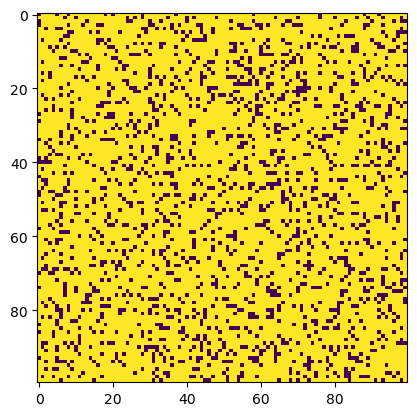

In [5]:
# 2D Ising model

import numpy as np
import matplotlib.pyplot as plt


# System parameters
N = 100
J=1
k=1
T = 1
B=30
mu = 1

# Iterations

M=10000

def energy(system):
    firstTerm = 0
    for col in range(N-1):
        firstTerm += system[:,col]*system[:,col+1]
        firstTerm += system[col, :]*system[col+1, :]
    firstTerm += system[:,-1]*system[:,0] + system[-1,:]*system[0,:]
    firstTerm *= -J

    secondTerm = -B*mu*np.sum(system)

    return np.sum(firstTerm)+secondTerm

# Initial state
system = np.random.choice([-1,1], size=(N,N))

E0 = energy(system)

state = np.zeros((N,N,M))
state[:,:,0]=system

for i in range(1, M):
    system1 = system.copy()
    ind_x = np.random.randint(0,N)
    ind_y = np.random.randint(0, N)

    system1[ind_x, ind_y]*=-1

    E1 = energy(system1)
    
    if E1 < E0:
        system=system1.copy()
        E0=E1
    else:
        prob = np.exp( (E0-E1)/(k*T) )
        dice = np.random.random()
        if dice < prob:
            system=system1.copy()
            E0=E1
    state[:,:,i]=system

plt.imshow(system)
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

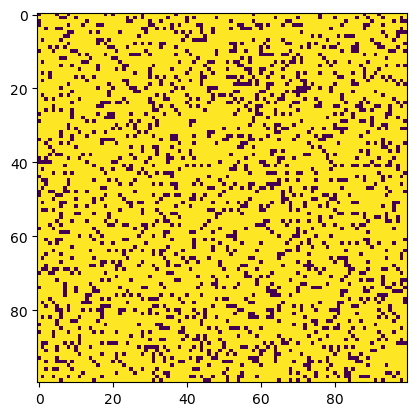

In [12]:
import matplotlib.animation as animation

fig, ax = plt.subplots()

ims = []
for i in range(0,M,200):
    im = ax.imshow(state[:,:,i], animated=True)
    if i == 0:
        ax.imshow(state[:,:,0])  # show an initial one first
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,
                                repeat_delay=1000)

ani.save("test.mp4")
print("Done")